# 機械学習実践プロジェクト_製造業生産データを活用した品質異常予測モデルの構築

### 実践プロジェクトの紹介

#### Bosch Production Line Performanceは、BoschとKaggleが2016年に開催した製造業向けの機械学習コンペティションであり、生産ラインから収集された大規模なデータを利用して、部品が品質検査で不合格になるかどうかを予測することを目的としています。
#### データには、部品がさまざまな生産ラインや工程を通過する際に記録された数値特徴量（968個）、カテゴリ特徴量（2,140個）、時刻特徴量（1,156個）が含まれており、数千個の匿名化された特徴量（温度、圧力、湿度、振動、設備停止時間など）に加えて、クラスの大きな偏りも存在します。
#### 参加者はこれらの生産工程データを用いて二値分類モデルを構築し、製品のResponse（0は正常、1は品質不良）を予測し、Matthews Correlation Coefficient（MCC）によってモデル性能を評価します。
#### このプロジェクトは、製造業における品質予測、生産工程分析、異常検知、特徴量エンジニアリング、不均衡データの分類など、実践的な機械学習を学ぶのに適しています。

#### MCC（Matthews相関係数）は、クラスに偏りがある二値分類でも、予測結果をバランスよく評価できる指標です。

## データセットの説明

このコンペティションのデータは、**Bosch（ボッシュ）の生産ラインを流れる部品について測定されたデータ**です。

各部品には、それぞれ一意の **Id** が割り当てられています。

このコンペティションの目的は、どの部品が**品質検査（Quality Control）で不合格になるか**を予測することです。

* `Response = 1`：品質検査で不合格となった部品
* `Response = 0`：品質検査を通過した部品

データセットには、非常に多くの**匿名化された特徴量（features）**が含まれています。

特徴量の名前には一定の命名規則があり、**生産ライン（Line）・ステーション（Station）・特徴量番号（Feature Number）**を確認できるようになっています。

例えば、

```text
L3_S36_F3939
```

は、以下を意味します。

* `L3`：生産ライン 3
* `S36`：ステーション 36
* `F3939`：特徴量番号 3939

データセットのサイズが非常に大きいため、データファイルは特徴量の種類ごとに、以下の3種類に分割されています。

* 数値特徴量（Numerical Features）
* カテゴリ特徴量（Categorical Features）
* 日付・時刻特徴量（Date Features）

日付・時刻特徴量には、**各測定が行われた時刻を示すタイムスタンプ**が含まれています。

各日付列の末尾にある番号は、対応する特徴量番号と関連しています。

例えば、

```text
L0_S0_D1
```

の値は、

```text
L0_S0_F0
```

が測定された時刻を表します。

このデータセットは、Kaggleでこれまで公開されたデータセットの中でも、**特徴量数の観点で非常に大規模なデータセットの一つ**です。

さらに、このコンペティションの正解ラベル（Ground Truth）は、**非常に不均衡（Highly Imbalanced）**になっています。

つまり、`Response = 1` となる不良品の数が非常に少なく、`Response = 0` の正常品が大部分を占めています。

そのため、

* 非常に多くの特徴量
* 強いクラス不均衡

という2つの特徴によって、難易度の高い機械学習問題となっています。

---

## ファイルの説明

* **`train_numeric.csv`**
  学習用データの**数値特徴量**が格納されています。
  このファイルには目的変数である **`Response`** も含まれています。

* **`test_numeric.csv`**
  テスト用データの**数値特徴量**が格納されています。
  これらの `Id` に対して `Response` を予測する必要があります。

* **`train_categorical.csv`**
  学習用データの**カテゴリ特徴量**が格納されています。

* **`test_categorical.csv`**
  テスト用データの**カテゴリ特徴量**が格納されています。

* **`train_date.csv`**
  学習用データの**日付・時刻特徴量**が格納されています。

* **`test_date.csv`**
  テスト用データの**日付・時刻特徴量**が格納されています。

* **`sample_submission.csv`**
  正しい提出形式を示した**サンプル提出ファイル**です。


In [39]:
import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

#### 以下のコードの主な目的は、大量の生産データから代表的な一部のデータを抽出し、後続の分析に使用できる形に準備することです。元のデータ量が非常に大きいため、PCへの負荷を抑えるために、生産日時の情報と各種数値データを分割して読み込み、それらを結合したうえで、各データの中から5％をランダムに抽出しています。その後、抽出したデータに対応する「正常／異常」の結果情報を付与します。最終的に得られたデータは、製品品質の分析、異常傾向の把握、予測モデルの構築などに利用するための基礎データとなります。

In [40]:
date_chunks = pd.read_csv("train_date.csv", index_col=0, chunksize=100000, dtype=np.float32)  # 日付データを10万行ずつ分割して読み込む
num_chunks = pd.read_csv("train_numeric.csv", index_col=0,
                         usecols=list(range(969)), chunksize=100000, dtype=np.float32)        # 数値データのうち、特徴量部分のみを10万行ずつ読み込む
# 日付特徴量と数値特徴量を結合し、各チャンクから5%をランダムサンプリングして学習データを作成する
X = pd.concat([pd.concat([dchunk, nchunk], axis=1).sample(frac=0.05)
               for dchunk, nchunk in zip(date_chunks, num_chunks)])
# サンプリングされたXと同じ行の目的変数Responseを取得する
y = pd.read_csv("train_numeric.csv", index_col=0, usecols=[0,969], dtype=np.float32).loc[X.index].values.ravel()
# pandas DataFrameからNumPy配列へ変換する
X = X.values

#### 以下のコードの目的は、製品に異常リスクがあるかどうかを判断するための予測モデルを作成し、事前に準備した生産データと「正常／異常」の実際の結果を使ってモデルに学習させることです。モデルは、過去のデータから生産条件と異常発生の関係や傾向を学習し、その後、新しいデータに対して「異常が発生する可能性」を判断するための基礎を作ります。また、base_score=0.005 は、学習開始前の異常発生の初期確率を低めに設定し、異常データが少ないという実際のデータ状況に近づけるための設定です。

In [41]:
# XGBoost分類モデルを作成する
# base_scoreには、学習開始時の予測値の基準として0.005を設定する
clf = XGBClassifier(base_score=0.005)
# 特徴量Xと正解ラベルyを使ってモデルを学習する
clf.fit(X, y);

#### 以下のコードの目的は、前のモデル学習の結果をもとに、製品が正常か異常かを判断するうえで、より参考になるデータ項目を見つけることです。まず、各データ項目の重要度をグラフで表示し、どの項目が結果に大きく影響しているかを確認します。その後、「重要度が0.005を超える」という基準で、多数のデータ項目の中から比較的重要な項目を抽出し、その位置番号を表示します。これにより、後続の分析で扱うデータ量を減らし、より重要な情報に重点を置くことができます。

[   0  535  946 1018 1019 1185 1188 1222 1226 1495 1497 1512 1516 1537
 1550 1616 1854 1858 1861 2089]


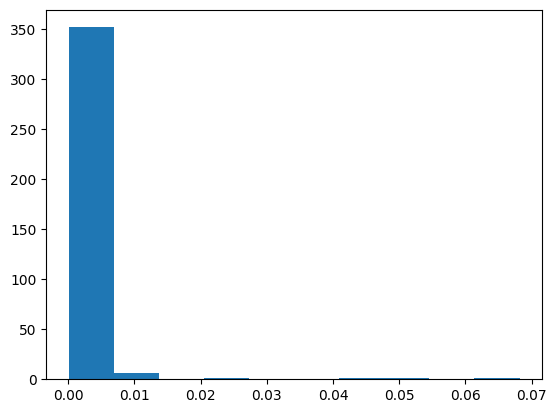

In [42]:
# 重要度が0より大きい特徴量について、重要度の分布をヒストグラムで確認する
plt.hist(clf.feature_importances_[clf.feature_importances_>0])
# 特徴量の重要度が0.005を超える項目のインデックスを抽出する
# 後続の分析で使用する特徴量を、重要度の高いものに絞り込むため
important_indices = np.where(clf.feature_importances_>0.005)[0]
# 抽出された重要な特徴量のインデックスを表示する
print(important_indices)

#### 以下のコードの目的は、前のステップで選定した「重要なデータ項目」だけを、全体の生産データから読み込むことです。すべての項目を読み込むのではなく、生産日時データと数値データから重要な項目のみを抽出し、それらを一つの分析用データとして結合します。あわせて、各生産データに対応する「正常／異常」の結果も読み込みます。これにより、重要な情報を維持しながら不要なデータ量を減らし、後続のモデル学習や品質異常の分析を効率的に行えるようにします。

In [43]:
# 日付特徴量の総数を設定する
# important_indices が日付データと数値データのどちらに属するかを判定するために使用する
n_date_features = 1156
# 重要度が高い特徴量だけを、日付データと数値データからそれぞれ読み込む
# その後、2種類の特徴量を横方向に結合して学習用データXを作成する
X = np.concatenate([
    pd.read_csv("train_date.csv", index_col=0, dtype=np.float32,
                usecols=np.concatenate([[0], important_indices[important_indices < n_date_features] + 1])).values,
    pd.read_csv("train_numeric.csv", index_col=0, dtype=np.float32,
                usecols=np.concatenate([[0], important_indices[important_indices >= n_date_features] + 1 - 1156])).values
], axis=1)
# 各データに対応する目的変数Responseを読み込み、
# 1次元のラベルデータyとして取得する
y = pd.read_csv("train_numeric.csv", index_col=0, dtype=np.float32, usecols=[0,969]).values.ravel()

#### 以下のコードの目的は、予測モデルが異なるデータに対しても安定して正しく機能するかを確認することです。全体のデータを3つのグループに分け、毎回そのうち2つを学習に使用し、残りの1つを検証に使用する処理を3回繰り返します。これにより、すべてのグループが順番に検証データとして使用されます。モデルは各検証データについて「異常が発生する可能性」を算出し、ROC-AUCという指標を使って「正常」と「異常」をどの程度正しく区別できるかを評価します。最後に、すべての検証結果をまとめて全体のROC-AUCを計算し、学習に使用していないデータに対してもモデルが十分な識別能力を維持できるかを確認します。

In [44]:
# XGBoostの分類モデルを作成する
# 木の深さを5に設定し、異常クラスの初期予測値を0.005に設定する
clf = XGBClassifier(
    max_depth=5,
    base_score=0.005)

# データを3分割し、クラス比率を保ちながら交差検証を行う
# shuffle=Trueでデータをランダムに並べ替え、random_stateで再現性を確保する
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42)

# 各サンプルの検証データに対する予測確率を保存する配列を用意する
preds = np.ones(y.shape[0])

# 3分割交差検証を順番に実行する
for i, (train, test) in enumerate(cv.split(X, y)):
    clf.fit(X[train], y[train])  # 現在のfoldの学習データを使ってモデルを学習する
    preds[test] = clf.predict_proba(X[test])[:, 1]  # 検証データがResponse=1となる確率を予測する
    print("fold {}, ROC AUC: {:.3f}".format(i,roc_auc_score(y[test], preds[test])))  # 現在のfoldにおけるROC-AUCを計算して表示する

# すべての検証データに対する予測結果を使って、全体のROC-AUCを計算する
print("Overall ROC AUC:", roc_auc_score(y, preds))

fold 0, ROC AUC: 0.679
fold 1, ROC AUC: 0.696
fold 2, ROC AUC: 0.695
Overall ROC AUC: 0.6900268470289077


#### 以下のコードの目的は、製品を「異常」と判定するための最適な判断基準を見つけることです。モデルは各製品について異常が発生する可能性を算出しますが、実際に異常と判断するためには、その確率に対する境界値を設定する必要があります。そこで、複数の異なる境界値を比較し、MCCという評価指標を使って、正常品と異常品をよりバランスよく判別できる基準を確認します。最後に、MCCが最も高くなる境界値を今後の正式な判定に使用する最適な基準として選び、そのときの最も高い評価結果も表示します。

0.17640809808317282


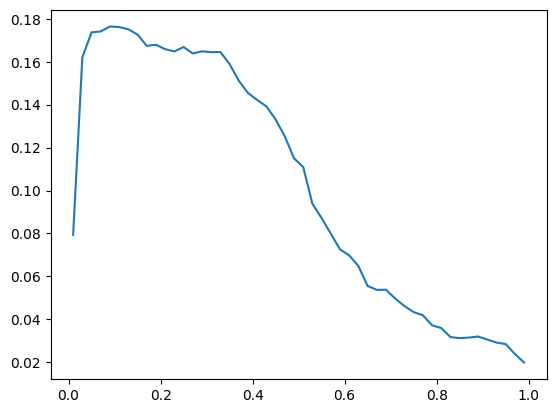

In [45]:
# 0.01～0.99の範囲で50個の判定しきい値を作成する
thresholds = np.linspace(0.01, 0.99, 50)
# 各しきい値で予測確率を0/1に分類し、
# MCC（Matthews相関係数）を計算してモデルの分類性能を評価する
mcc = np.array([matthews_corrcoef(y, preds>thr) for thr in thresholds])
# しきい値ごとのMCCをグラフで確認する
plt.plot(thresholds, mcc)
# MCCが最も高くなるしきい値を最適なしきい値として取得する
best_threshold = thresholds[mcc.argmax()]
# 最も高いMCCを表示する
print(mcc.max())

#### 以下のコードの目的は、最終的な予測に使用するテストデータを準備することです。すべての元データを再度使用するのではなく、前のステップで重要と判断された項目だけをテストデータから読み込みます。具体的には、生産日時に関するデータと数値型の生産データから必要な項目をそれぞれ抽出し、それらを一つのデータとして結合します。これにより、不要なデータ処理を減らしながら、モデルの学習時と同じ項目を使って、新しい製品に異常リスクがあるかどうかを予測するための準備を行います。

In [46]:
# テストデータから、事前に重要と判断された特徴量だけを読み込む
# 日付データと数値データをそれぞれ抽出し、横方向に結合して予測用データXを作成する
X = np.concatenate([
    pd.read_csv("test_date.csv", index_col=0, dtype=np.float32,
                usecols=np.concatenate([[0], important_indices[important_indices<1156]+1])).values,
    pd.read_csv("test_numeric.csv", index_col=0, dtype=np.float32,
                usecols=np.concatenate([[0], important_indices[important_indices>=1156] +1 - 1156])).values
], axis=1)

#### 以下のコードの目的は、新しい製品データに対して最終的な判定を行うことです。まず、モデルが各製品について異常が発生する可能性を算出し、その結果を前のステップで決定した最適な判断基準と比較します。異常の可能性がその基準を上回った場合は「異常」、下回った場合は「正常」と判定します。これにより、モデルが出力した確率を、より分かりやすい「正常／異常」の分類結果に変換し、品質管理や異常品の抽出に活用できるようにします。

In [47]:
# テストデータごとに「異常（Response=1）」となる予測確率を計算し、
# その確率が最適なしきい値を超えた場合は1、超えない場合は0として最終判定する
preds = (clf.predict_proba(X)[:,1] > best_threshold).astype(np.int8)

#### 以下のコードの目的は、モデルが最終的に判定した「正常／異常」の結果を所定の形式に整理し、正式な出力ファイルとして保存することです。まず、あらかじめ用意された提出用テンプレートを読み込み、前のステップで得られた予測結果を Response 欄に反映します。その後、完成した結果を圧縮ファイルとして保存します。これにより、モデルによる分析結果を統一された形式にまとめ、結果確認、評価、提出、またはその後の活用がしやすくなります。

In [48]:
# 提出用のサンプルファイルを読み込む
sub = pd.read_csv("sample_submission.csv", index_col=0)
# モデルによる「正常／異常」の予測結果をResponse列に設定する
sub["Response"] = preds
# 提出用ファイルとしてgzip形式で圧縮して保存する
sub.to_csv("submission.csv.gz", compression="gzip")

In [49]:
sub.to_csv("submission.csv")

In [50]:
submission = pd.read_csv("submission.csv")  # 最終的に生成した submission.csv を読み込む
submission.head(5)  # 先頭5行を確認する

,Id,Response
0,1,0
1,2,0
2,3,0
3,5,0
4,8,0


In [51]:
print(submission.shape)                        # データの行数と列数を確認する
print(submission["Response"].value_counts())   # 正常／異常の予測件数を確認する

(1183748, 2)
Response
0    1178782
1       4966
Name: count, dtype: int64


In [52]:
print("異常予測数:", (submission["Response"] == 1).sum())  # 異常と予測された件数を表示する
print("正常予測数:", (submission["Response"] == 0).sum())  # 正常と予測された件数を表示する

異常予測数: 4966
正常予測数: 1178782
